In [1]:
#Problem C: Fourier Neural Operator (FNO) surrogate a(x,y) -> u(x,y).

import os, time
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

# Load data

with h5py.File('ProblemC_dataset.h5', 'r') as data:
    a_train = torch.from_numpy(data["a_train"][:]).float()   # (1000,128,128)
    u_train = torch.from_numpy(data["u_train"][:]).float()
    a_test  = torch.from_numpy(data["a_test"][:]).float()    # (200,128,128)
    u_test  = torch.from_numpy(data["u_test"][:]).float()
    X = torch.tensor(np.array(data['X']), dtype=dtype)
    Y = torch.tensor(np.array(data['Y']), dtype=dtype)

S = a_train.shape[-1]  # 128

#Normalize the input (helps optimization)
a_mean, a_std = a_train.mean(), a_train.std()
a_train_n = (a_train - a_mean) / a_std
a_test_n  = (a_test  - a_mean) / a_std

In [2]:
#Positional grid appended as extra input channels(standard FNO practice)
grid = torch.stack([X, Y], dim=0)  # (2,128,128)

def with_grid(a):
    """a: (B,128,128) -> (B,3,128,128) with x,y coordinate channels."""
    B = a.shape[0]
    g = grid.unsqueeze(0).expand(B, -1, -1, -1).to(a)
    return torch.cat([a.unsqueeze(1), g], dim=1)

In [3]:
# FNO built 
class SpectralConv2d(torch.nn.Module):
    """2D spectral convolution: FFT -> multiply low modes by learned complex
    weights -> inverse FFT. Written directly with torch.fft (no libraries)."""
    def __init__(self, in_ch, out_ch, modes1, modes2):
        super().__init__()
        self.in_ch, self.out_ch = in_ch, out_ch
        self.modes1, self.modes2 = modes1, modes2  # retained modes per dim
        scale = 1.0 / (in_ch * out_ch)
        #complex weights for the low-frequency corner blocks
        self.w1 = torch.nn.Parameter(
            scale * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))
        self.w2 = torch.nn.Parameter(
            scale * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))

    def forward(self, x):
        B, C, H, W = x.shape
        x_ft = torch.fft.rfft2(x)    #(B,C,H,W//2+1)complex
        out_ft = torch.zeros(B, self.out_ch, H, W // 2 + 1,
                             dtype=torch.cfloat, device=x.device)
        m1, m2 = self.modes1, self.modes2
        #low positive frequencies
        out_ft[:, :, :m1, :m2] = torch.einsum(
            'bixy,ioxy->boxy', x_ft[:, :, :m1, :m2], self.w1)
        #low negative frequencies
        out_ft[:, :, -m1:, :m2] = torch.einsum(
            'bixy,ioxy->boxy', x_ft[:, :, -m1:, :m2], self.w2)
        return torch.fft.irfft2(out_ft, s=(H, W))


In [4]:
class FNO2d(torch.nn.Module):
    def __init__(self, modes=12, width=32, n_layers=4):
        super().__init__()
        self.lift = torch.nn.Conv2d(3, width, 1)  # input: a + x + y channels
        self.spectral = torch.nn.ModuleList(
            [SpectralConv2d(width, width, modes, modes) for _ in range(n_layers)])
        self.pointwise = torch.nn.ModuleList(
            [torch.nn.Conv2d(width, width, 1) for _ in range(n_layers)])
        self.proj1 = torch.nn.Conv2d(width, 128, 1)
        self.proj2 = torch.nn.Conv2d(128, 1, 1)

    def forward(self, x):
        x = self.lift(x)
        for spec, pw in zip(self.spectral, self.pointwise):
            x = torch.nn.functional.gelu(spec(x) + pw(x))
        x = torch.nn.functional.gelu(self.proj1(x))
        return self.proj2(x)

In [5]:
model = FNO2d(modes=12, width=32, n_layers=4).to(device)
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))

opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs, batch_size = 100, 20
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

def rel_l2(pred, true):
    num = ((pred - true) ** 2).sum(dim=(1, 2, 3))
    den = (true ** 2).sum(dim=(1, 2, 3))
    return torch.mean(torch.sqrt(num / den)).item()



Trainable parameters: 1188353


In [6]:
#Training (relative L2 loss and standard one for FNO)
errors = []
t0 = time.time()
for ep in range(epochs):
    model.train()
    perm = torch.randperm(a_train_n.shape[0])
    a_train_n, u_train = a_train_n[perm], u_train[perm]
    for i in range(0, a_train_n.shape[0], batch_size):
        ab = with_grid(a_train_n[i:i+batch_size]).to(device)
        ub = u_train[i:i+batch_size].unsqueeze(1).to(device)
        opt.zero_grad()
        pred = model(ab)
        # relative L2 loss per sample
        num = ((pred - ub) ** 2).sum(dim=(1, 2, 3)).sqrt()
        den = (ub ** 2).sum(dim=(1, 2, 3)).sqrt()
        loss = (num / den).mean()
        loss.backward()
        opt.step()
    sched.step()
    model.eval()
    with torch.no_grad():
        preds = []
        for i in range(0, a_test_n.shape[0], 50):
            preds.append(model(with_grid(a_test_n[i:i+50]).to(device)).cpu())
        u_pred_test = torch.cat(preds)
        err = rel_l2(u_pred_test, u_test.unsqueeze(1))
        errors.append(err)
    print(f"Epoch {ep}: loss={loss.item():.4e}  test_err={err:.4f}  ({time.time()-t0:.0f}s)",
          flush=True)
print("Final relative L2 error:", errors[-1])
np.save('C_fno_errors.npy', np.array(errors))
torch.save(model.state_dict(), 'C_fno_model.pt')

Epoch 0: loss=5.4516e-02  test_err=0.0539  (3s)
Epoch 1: loss=2.8686e-02  test_err=0.0231  (6s)
Epoch 2: loss=1.7733e-02  test_err=0.0191  (8s)
Epoch 3: loss=1.9748e-02  test_err=0.0156  (10s)
Epoch 4: loss=1.4975e-02  test_err=0.0200  (12s)
Epoch 5: loss=1.5766e-02  test_err=0.0125  (15s)
Epoch 6: loss=1.1888e-02  test_err=0.0147  (17s)
Epoch 7: loss=9.8645e-03  test_err=0.0143  (19s)
Epoch 8: loss=1.0946e-02  test_err=0.0119  (21s)
Epoch 9: loss=8.7109e-03  test_err=0.0113  (24s)
Epoch 10: loss=1.0908e-02  test_err=0.0112  (26s)
Epoch 11: loss=1.0159e-02  test_err=0.0215  (28s)
Epoch 12: loss=1.3303e-02  test_err=0.0147  (30s)
Epoch 13: loss=1.8035e-02  test_err=0.0139  (33s)
Epoch 14: loss=1.2563e-02  test_err=0.0133  (35s)
Epoch 15: loss=1.2314e-02  test_err=0.0142  (37s)
Epoch 16: loss=1.6174e-02  test_err=0.0158  (40s)
Epoch 17: loss=1.1292e-02  test_err=0.0091  (42s)
Epoch 18: loss=7.4075e-03  test_err=0.0099  (44s)
Epoch 19: loss=9.8069e-03  test_err=0.0090  (46s)
Epoch 20: los

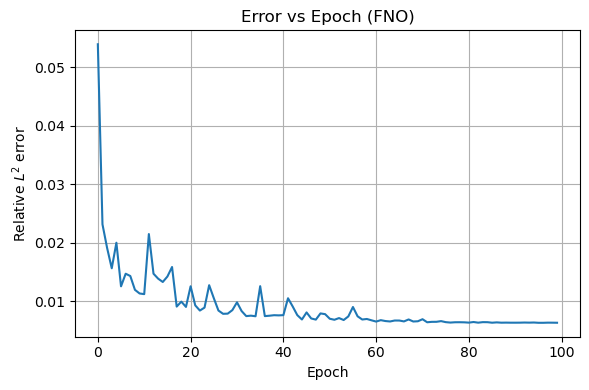

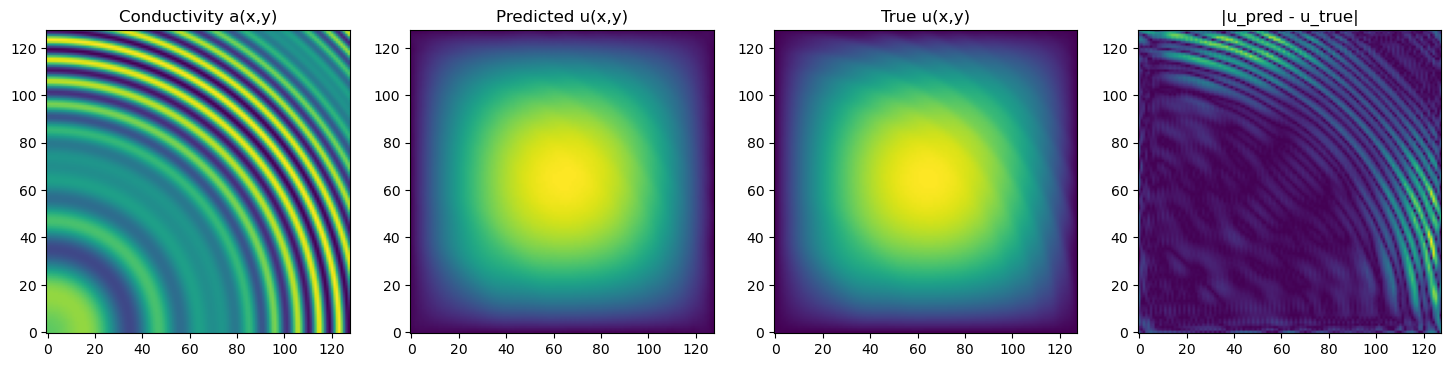

In [7]:
# Required figures

plt.figure(figsize=(6, 4))
plt.plot(errors)
plt.xlabel("Epoch"); plt.ylabel("Relative $L^2$ error"); plt.grid(True)
plt.title("Error vs Epoch (FNO)")
plt.tight_layout(); plt.savefig('C_error_vs_epoch.png', dpi=150); plt.show()

a0 = a_test[0].numpy()
u_true0 = u_test[0].numpy()
u_pred0 = u_pred_test[0, 0].numpy()
err0 = np.abs(u_pred0 - u_true0)
#for arr, name, title in [(a0, 'C_a', 'Input conductivity $a(x,y)$'),
                         #(u_pred0, 'C_u_pred', 'Predicted temperature $u_{pred}(x,y)$'),
                        # (u_true0, 'C_u_true', 'Ground truth $u_{true}(x,y)$'),
                        # (err0, 'C_abs_err', 'Pointwise absolute error $|u_{pred}-u_{true}|$')]:
   # plt.figure(figsize=(5, 4))
   # im = plt.imshow(arr, origin='lower', extent=[0, 1, 0, 1])
    #plt.colorbar(im); plt.title(title); plt.xlabel('$x$'); plt.ylabel('$y$')
   # plt.tight_layout(); plt.savefig(f'{name}.png', dpi=150); plt.show()

fig, axes = plt.subplots(1,4,figsize=(18,4))
axes[0].imshow(a0, origin='lower'); axes[0].set_title("Conductivity a(x,y)")
axes[1].imshow(u_pred0, origin='lower'); axes[1].set_title("Predicted u(x,y)")
axes[2].imshow(u_true0, origin='lower'); axes[2].set_title("True u(x,y)")
axes[3].imshow(err0, origin='lower'); axes[3].set_title("|u_pred - u_true|")
plt.savefig("C_results_panel.png", dpi=300, bbox_inches="tight")
plt.show()